In [1]:
import os, math
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader, Dataset
import sklearn
from sklearn.preprocessing import OneHotEncoder
from utils.utils import create_directory
from classifiers import resnet_pytorch


In [2]:
# defining the actual model
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import os
import matplotlib
import csv
matplotlib.use('agg')
import matplotlib.pyplot as plt
from utils.utils import save_test_duration, save_logs, calculate_metrics

In [3]:
# setup save locations
classifier_name = 'resnet_pytorch'
archive_name = 'custom'
dataset_name = 'h264_all'
itr_num = 1

root_dir = "/mnt/hbnas/home/fgan/Proj-Entropy/Video_Classification_Model/dl-4-tsc"

print('Method: ', archive_name, dataset_name, classifier_name, itr_num)

output_directory_tmpl = f"{root_dir}/results/{classifier_name}/{archive_name}/{dataset_name}_itr_"
for i in range(1, 100):     # at most 100 iterations
    output_directory = create_directory(output_directory_tmpl+str(i))
    if output_directory != None:
        break
print(output_directory)


Method:  custom h264_all resnet_pytorch 1
/mnt/hbnas/home/fgan/Proj-Entropy/Video_Classification_Model/dl-4-tsc/results/resnet_pytorch/custom/h264_all_itr_16


In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1):
        super(ResidualBlock, self).__init__()
        # padding = (kernel_size - 1) // 2
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size[0], stride=stride, padding='same')
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU(inplace=False)
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size[1], stride=stride, padding='same')
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU(inplace=False)      # for completionist sanity sake
        
        self.conv3 = nn.Conv1d(out_channels, out_channels, kernel_size[2], stride=stride, padding='same')
        self.bn3 = nn.BatchNorm1d(out_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                # expand in_channels to equal out_channel to enable element-wise addition
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
            )
        else:
            self.shortcut = nn.Sequential()
        
        self.bn4 = nn.BatchNorm1d(out_channels)     # exclusively for shortcut, to bn raw inputs
        self.relu3 = nn.ReLU(inplace=False)

    def forward(self, x):
        out = self.relu1(self.bn1(self.conv1(x)))
        out = self.relu2(self.bn2(self.conv2(out)))
        out = self.relu3(self.bn3(self.conv3(out)) + self.bn4(self.shortcut(x)))
        return out


class ResNet(nn.Module):
    def __init__(self, input_shape, num_classes):
        super(ResNet, self).__init__()
        n_feature_maps = 64

        self.layer1 = ResidualBlock(input_shape[0], n_feature_maps, kernel_size=[8, 5, 3])
        self.layer2 = ResidualBlock(n_feature_maps, n_feature_maps * 2, kernel_size=[8, 5, 3])
        self.layer3 = ResidualBlock(n_feature_maps * 2, n_feature_maps * 2, kernel_size=[8, 5, 3])
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(n_feature_maps * 2, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.gap(out)
        # out = out.view(out.size(0), -1)     # imo, ambiguous intent
        out = torch.flatten(out, 1) # flatten all dimensions except batch
        out = self.fc(out)
        return out




In [5]:
## really see the model and compare with tf implementation
from torchinfo import summary
torch.autograd.set_detect_anomaly(True)
model = ResNet( input_shape=(1, 3000), num_classes=11 )
summary(model, input_size=(1, 1, 3000))

/mnt/hbnas/home/fgan/miniconda3/envs/py310-torch230/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/conda/conda-bld/pytorch_1716905971132/work/aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv1d(input, weight, bias, self.stride,


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 11]                   --
├─ResidualBlock: 1-1                     [1, 64, 3000]             --
│    └─Conv1d: 2-1                       [1, 64, 3000]             576
│    └─BatchNorm1d: 2-2                  [1, 64, 3000]             128
│    └─ReLU: 2-3                         [1, 64, 3000]             --
│    └─Conv1d: 2-4                       [1, 64, 3000]             20,544
│    └─BatchNorm1d: 2-5                  [1, 64, 3000]             128
│    └─ReLU: 2-6                         [1, 64, 3000]             --
│    └─Conv1d: 2-7                       [1, 64, 3000]             12,352
│    └─BatchNorm1d: 2-8                  [1, 64, 3000]             128
│    └─Sequential: 2-9                   [1, 64, 3000]             --
│    │    └─Conv1d: 3-1                  [1, 64, 3000]             128
│    └─BatchNorm1d: 2-10                 [1, 64, 3000]             128
│

In [8]:
### Here, we write the entire data, training, eval loop, in one go ###

In [6]:
### Data Loading + Transform + Create Datasets & Dataloaders ###
import torch
from sklearn.preprocessing import OneHotEncoder

# Load data from the DataFrame
X = pd.read_csv("train-data.csv").values
y = pd.read_csv("train-labels.csv").values

# permute and split train/val set (why train_test_split when I could just use numpy)
percentage = 0.1
threshold = math.floor(len(X)*percentage)
shuffled_indices = np.random.permutation(len(X))
train_idx, val_idx = shuffled_indices[threshold:], shuffled_indices[:threshold]

# train_test_split in pure numpy
x_train, y_train, x_val, y_val = (X[train_idx, :],
                                  y[train_idx, :],
                                  X[val_idx, :],
                                  y[val_idx, :])

# one hot encode categorical variable
enc = OneHotEncoder(categories='auto')
enc.fit(y.reshape(-1, 1))            # just formality, y already in good shape
y_train = enc.transform(y_train).toarray()
y_val = enc.transform(y_val).toarray()

nb_classes = len(enc.categories_[0])
y_train.shape, y_val.shape, enc.categories_

# normalize X (each example individually)
x_train_mean, x_train_std = x_train.mean(axis=1, keepdims=True), x_train.std(axis=1, keepdims=True)
x_train = (x_train - x_train_mean) / x_train_std

x_val_mean, x_val_std = x_val.mean(axis=1, keepdims=True), x_val.std(axis=1, keepdims=True)
x_val = (x_val - x_val_mean) / x_val_std


# add an extra C dimension because model expects it
if len(x_train.shape) == 2:  # if univariate
    # add a dimension to make it multivariate with one dimension 
    x_train = x_train.reshape((x_train.shape[0], 1, x_train.shape[1]))
    x_val = x_val.reshape((x_val.shape[0], 1,x_val.shape[1]))


## creating data loaders
# Convert the numpy array to a PyTorch tensor
train_dataset = TensorDataset(torch.tensor(x_train, dtype=torch.float32),
                            torch.tensor(y_train, dtype=torch.float32))
val_dataset   = TensorDataset(torch.tensor(x_val, dtype=torch.float32),
                            torch.tensor(y_val, dtype=torch.float32))

### Create a DataLoader from the TensorDataset
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_dataloader   = DataLoader(val_dataset  , batch_size=batch_size, shuffle=False)



In [7]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim import Adam

# Hyperparameters
nb_epochs = 10
early_stop_patience = 80  # Patience level for early stopping
lr = 0.001
min_lr = 0.00001
lr_reduce_factor = 0.1
lr_patience = 40

### Create model
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
input_shape = x_train.shape[1:]     # (C, N) = (1, 3000)
model = ResNet(input_shape, nb_classes).to(device)


### define: loss fn, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=lr)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=lr_reduce_factor, 
                              patience=lr_patience, verbose=True)

print('Begin Training...')
### loop
train_acc, test_acc = [], []
patience_cnt = 0

for epoch in range(nb_epochs):
    start = time.perf_counter()
    
    ### training loop
    model.train()
    train_loss = 0
    train_logits, train_truth = [], []
    for batch_num, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        batch_loss = criterion(logits, y)
        batch_loss.backward()
        optimizer.step()
        
        # mark down results for metric calculations
        train_logits += logits
        train_truth += y
        train_loss += batch_loss
        
    train_loss /= len(train_dataloader.dataset)

    ### eval loop
    model.eval()
    with torch.no_grad():
        # eval
        val_loss = 0     # for lr scheduler
        val_logits, val_truth = [], []
        for batch_num, (X, y) in enumerate(val_dataloader):
            X, y = X.to(device), y.to(device)
            logits = model(X)
            val_logits += logits
            val_truth += y
            val_loss += criterion(logits, y) * len(y)     # properly weighting each batch loss, 
        val_loss /= len(val_dataloader.dataset)
        
        # calculate metrics (bit wonky on logits, converting to numerical categories)
        
        metrics = calculate_metrics(
            torch.stack(train_truth).max(dim=1)[1].cpu(), 
            torch.stack(train_logits).max(dim=1)[1].cpu(), 
            0.0, 
            torch.stack(val_truth).max(dim=1)[1].cpu(), 
            torch.stack(val_logits).max(dim=1)[1].cpu())
        print(metrics)
        
        train_acc.append(metrics['accuracy'][0])
        test_acc.append(metrics['accuracy_val'][0])
        
        # step lr scheduler
        scheduler.step(val_loss)
        
        # print out metrics
        if epoch % 1 == 0 or epoch == nb_epochs-1:
            lr = scheduler.optimizer.param_groups[0]['lr']
            dt = time.perf_counter() - start
            
            print(f'Epoch {epoch+1}/{nb_epochs}' + \
                  f' | Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}' + \
                  f' | Acc: {train_acc[-1]:.4f} | Val Acc: {test_acc[-1]:.4f}' + \
                  f' | lr: {lr:.4f} | dt: {dt:.3f}s  ')
    
    # always save the last model, in case of crash
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc[-1],
        'val_acc': test_acc[-1],
    }, os.path.join(output_directory, 'last_model.pt'))
    
    # and save best model by val acc
    if test_acc[-1] >= max(test_acc):
        print(f'### Saving Best Model: val_acc = {test_acc[-1]} ###')
        patience_cnt = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc[-1],
            'val_acc': test_acc[-1],
        }, os.path.join(output_directory, 'best_model.pt'))
    else:       # Early stopping
        patience_cnt += 1
        if patience_cnt >= early_stop_patience:
            print("## Early stopping triggered. ##")
            break
    
print('Training finished.')


/mnt/hbnas/home/fgan/miniconda3/envs/py310-torch230/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Begin Training...


/mnt/hbnas/home/fgan/miniconda3/envs/py310-torch230/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   precision  accuracy    recall  duration  accuracy_val
0   0.230827  0.353067  0.257801       0.0      0.305288
Epoch 1/10 | Loss: 0.0301 | Val Loss: 1.9477 | Acc: 0.3531 | Val Acc: 0.3053 | lr: 0.0010 | dt: 11.022s  
### Saving Best Model: val_acc = 0.30528846153846156 ###


/mnt/hbnas/home/fgan/miniconda3/envs/py310-torch230/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   precision  accuracy    recall  duration  accuracy_val
0   0.322962  0.448267  0.339144       0.0      0.382212
Epoch 2/10 | Loss: 0.0256 | Val Loss: 1.7187 | Acc: 0.4483 | Val Acc: 0.3822 | lr: 0.0010 | dt: 9.222s  
### Saving Best Model: val_acc = 0.38221153846153844 ###


/mnt/hbnas/home/fgan/miniconda3/envs/py310-torch230/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


   precision  accuracy    recall  duration  accuracy_val
0   0.436359  0.501067  0.391502       0.0        0.3125
Epoch 3/10 | Loss: 0.0232 | Val Loss: 2.0609 | Acc: 0.5011 | Val Acc: 0.3125 | lr: 0.0010 | dt: 10.002s  
   precision  accuracy    recall  duration  accuracy_val
0   0.543723    0.5312  0.430102       0.0      0.324519
Epoch 4/10 | Loss: 0.0217 | Val Loss: 2.2275 | Acc: 0.5312 | Val Acc: 0.3245 | lr: 0.0010 | dt: 9.225s  
   precision  accuracy    recall  duration  accuracy_val
0   0.574014    0.5648  0.479705       0.0      0.389423
Epoch 5/10 | Loss: 0.0203 | Val Loss: 2.0061 | Acc: 0.5648 | Val Acc: 0.3894 | lr: 0.0010 | dt: 8.878s  
### Saving Best Model: val_acc = 0.3894230769230769 ###
   precision  accuracy    recall  duration  accuracy_val
0   0.593483    0.5832  0.511312       0.0      0.411058
Epoch 6/10 | Loss: 0.0193 | Val Loss: 1.8064 | Acc: 0.5832 | Val Acc: 0.4111 | lr: 0.0010 | dt: 8.930s  
### Saving Best Model: val_acc = 0.4110576923076923 ###
   precisio

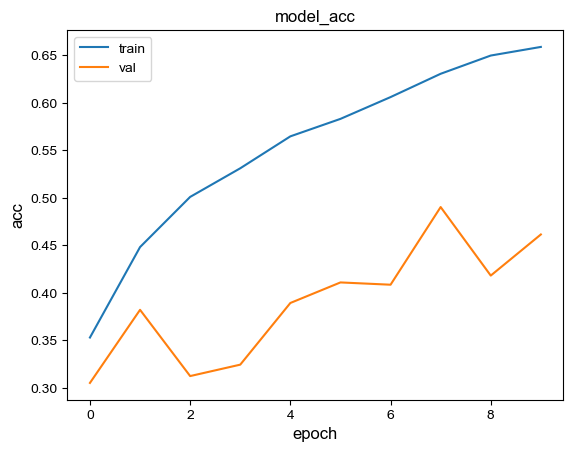

In [25]:
%matplotlib inline
# visualization
plt.rcParams["font.family"] = "sans-serif"

plt.figure()
plt.plot(train_acc)
plt.plot(test_acc)

plt.title('model_acc')
plt.ylabel("acc", fontsize='large')
plt.xlabel('epoch', fontsize='large')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig(os.path.join(output_directory, 'output-hevc_4400_REALLY_FIXED.png'), 
            bbox_inches='tight')

with open(os.path.join(output_directory, 'output-hevc_4400_REALLY_FIXED.csv'), 
          'w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['train_acc']+[float(i) for i in train_acc])
    writer.writerow(['test_acc']+[float(i) for i in test_acc])





In [37]:
# completely separate testing
model_test = ResNet(input_shape=(1,3000), num_classes=11).to(device)

checkpoint = torch.load(os.path.join(output_directory, 'best_model.pt'))
model_test.load_state_dict(checkpoint['model_state_dict'])
epoch = checkpoint['epoch']

model_test.eval()

with torch.no_grad():
    # for batch_num, (X, y) in enumerate(val_dataloader):
    #     X, y = X.to(device), y.to(device)
    #     logits = model(X)
    #     max_vals, max_args = torch.max(logits, 1)     # reduce on dimension 1
    #     val_pred += list(max_args.cpu().numpy())
    #     val_loss += criterion(logits, y) * len(y)     # properly weighting each batch loss, 
    # val_loss /= len(val_dataloader.dataset)
    
    val_loss = 0     # for lr scheduler
    val_logits, val_truth = [], []
    for batch_num, (X, y) in enumerate(val_dataloader):
        X, y = X.to(device), y.to(device)
        logits = model_test(X)
        val_logits += logits
        val_truth += y
        val_loss += criterion(logits, y) * len(y)     # properly weighting each batch loss, 
    val_loss /= len(val_dataloader.dataset)
    
    
# calculate_metrics([0], [0], 0.0, val_truth, val_logits)

calculate_metrics(
    torch.stack(val_truth).max(dim=1)[1].cpu(), 
    torch.stack(val_logits).max(dim=1)[1].cpu(), 
    0.0)


/mnt/hbnas/home/fgan/miniconda3/envs/py310-torch230/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,accuracy,recall,duration
0,0.611042,0.490385,0.447449,0.0


In [36]:
torch.stack(val_truth).max(dim=1)[1].cpu()[:50] 

tensor([4, 0, 8, 7, 2, 5, 5, 6, 3, 8, 9, 0, 4, 6, 2, 7, 6, 8, 2, 6, 2, 2, 1, 4,
        2, 2, 9, 7, 6, 2, 8, 9, 2, 9, 8, 8, 8, 7, 8, 1, 4, 9, 0, 0, 6, 5, 8, 8,
        3, 5])

In [35]:
torch.stack(val_logits).max(dim=1)[1].cpu()[:50]

tensor([2, 7, 8, 7, 2, 5, 2, 2, 0, 8, 9, 0, 2, 2, 5, 7, 9, 8, 2, 2, 2, 2, 2, 4,
        2, 2, 0, 7, 2, 7, 8, 9, 2, 5, 7, 8, 0, 7, 0, 8, 2, 9, 2, 0, 9, 5, 8, 7,
        0, 5])

In [16]:
scheduler.optimizer.param_groups[0]['lr']

0.001

In [38]:
x = ([
    torch.tensor([0, 0, 1]).to('cuda'),
    torch.tensor([1, 0, 0]).to('cuda')
    ])

y = ([
    torch.tensor([0, 0, 1]).to('cuda'),
    torch.tensor([0, 0, 1]).to('cuda')
    ])

torch.stack(x).max(dim=1)[1]
torch.stack(y).max(dim=1)[1]

calculate_metrics(torch.stack(x).max(dim=1)[1].cpu(), 
                  torch.stack(y).max(dim=1)[1].cpu(), 0)

# val, idx = torch.stack(x).max(dim=1)
# calculate_metrics(idx.cpu(), [2, 0], 0.0)



# x = np.array(x)
# np.argmax(x, axis=1)

/mnt/hbnas/home/fgan/miniconda3/envs/py310-torch230/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,accuracy,recall,duration
0,0.25,0.5,0.5,0


In [65]:
# calculate_metrics([ [0, 1], [0, 1], [0, 1] ], [ [1, 0], [0, 1], [0, 1] ], 0.0)



calculate_metrics([1, 2, 3], [1, 4, 1], 0.0)



/mnt/hbnas/home/fgan/miniconda3/envs/py310-torch230/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/hbnas/home/fgan/miniconda3/envs/py310-torch230/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,accuracy,recall,duration
0,0.125,0.333333,0.25,0.0


In [16]:
print("Done.")

Done.
